<a href="https://colab.research.google.com/github/m-zafari/Digit-Recognition-With-MNIST-Dataset/blob/main/Tenosrflw_HRN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load data
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


In [ ]:
# Normalize intensity of images to make it in the range [0,1] since 255 is the max (white).
# and change the format from numpy float64 to float32 to minimize computation and become faster
x_train = x_train.reshape(-1, 28*28).astype('float32') / 255
x_test = x_test.reshape(-1, 28*28).astype('float32') / 255

each 2D image is now transformed into a 1D vector with dimension [1, 28x28] = [1, 784]

In [ ]:
print(x_train.shape)

(60000, 784)


In [ ]:
print(y_train.shape)

(60000,)


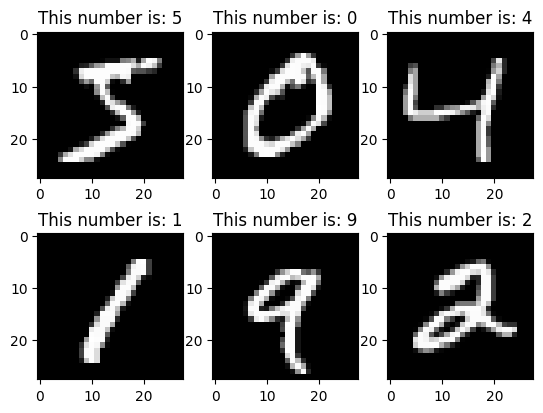

In [ ]:
for i in range(6):
  plt.subplot(2,3,i + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap=plt.get_cmap("gray"))
  plt.title(f'This number is: {y_train[i]}')
plt.show()

In [ ]:
solvers = [keras.optimizers.SGD(learning_rate= 0.01),
           keras.optimizers.Adam(learning_rate=0.01),
           keras.optimizers.RMSprop(learning_rate= 0.01),
           keras.optimizers.AdamW(learning_rate= 0.01),
           keras.optimizers.Adadelta(learning_rate= 0.01),
           keras.optimizers.Adagrad(learning_rate= 0.01),
           keras.optimizers.Adamax(learning_rate= 0.01),
           keras.optimizers.Adafactor(learning_rate= 0.01),
           keras.optimizers.Nadam(learning_rate= 0.01),
           keras.optimizers.Ftrl(learning_rate= 0.01)]

In [ ]:
activations = ['relu', 'selu', 'elu', 'tanh']

This problem **can't be solved by** solver = "**lbfgs**"

In [ ]:
models = list()
count1 = 0
for slvr in solvers:
  model_temp = list()

  for act in activations:
    j_model = keras.Sequential([
        keras.Input(shape=(784)),

        # dense layer 1
        keras.layers.Dense(50, activation = act),

        # dense layer 2
        keras.layers.Dense(20, activation = act),

        # output layer
        keras.layers.Dense(10, activation='softmax'),
    ])
    j_model.compile(
    optimizer=slvr,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )
    model_temp.append(j_model)
    # print(np.array(model_temp).shape)

  models.append(model_temp)
  # print(np.array(models).shape)
  # print(len(models))

In [ ]:
print(np.array(models).shape)

(10, 4)


In [ ]:
history1 = list()
for i in range(len(solvers)):
  history_temp = list()
  j_history = models[i][0].fit(x_train, y_train, batch_size = 32, epochs = 10, verbose = 2)
  history_temp.append(j_history)
  history1.append(history_temp)

Epoch 1/10
1875/1875 - 3s - loss: 0.0293 - accuracy: 0.9926 - 3s/epoch - 2ms/step
Epoch 2/10
1875/1875 - 4s - loss: 0.0288 - accuracy: 0.9923 - 4s/epoch - 2ms/step
Epoch 3/10
1875/1875 - 3s - loss: 0.0276 - accuracy: 0.9929 - 3s/epoch - 2ms/step
Epoch 4/10
1875/1875 - 3s - loss: 0.0269 - accuracy: 0.9931 - 3s/epoch - 2ms/step
Epoch 5/10
1875/1875 - 3s - loss: 0.0260 - accuracy: 0.9935 - 3s/epoch - 2ms/step
Epoch 6/10
1875/1875 - 4s - loss: 0.0253 - accuracy: 0.9938 - 4s/epoch - 2ms/step
Epoch 7/10
1875/1875 - 3s - loss: 0.0244 - accuracy: 0.9940 - 3s/epoch - 2ms/step
Epoch 8/10
1875/1875 - 3s - loss: 0.0237 - accuracy: 0.9942 - 3s/epoch - 2ms/step
Epoch 9/10
1875/1875 - 3s - loss: 0.0229 - accuracy: 0.9944 - 3s/epoch - 2ms/step
Epoch 10/10
1875/1875 - 4s - loss: 0.0223 - accuracy: 0.9949 - 4s/epoch - 2ms/step
Epoch 1/10
1875/1875 - 4s - loss: 0.0769 - accuracy: 0.9813 - 4s/epoch - 2ms/step
Epoch 2/10
1875/1875 - 3s - loss: 0.0796 - accuracy: 0.9808 - 3s/epoch - 2ms/step
Epoch 3/10
1875

In [ ]:
history2 = list()
for i in range(len(solvers)):
  history_temp = list()
  j_history = models[i][1].fit(x_train, y_train, batch_size = 32, epochs = 10, verbose = 2)
  history_temp.append(j_history)
  history2.append(history_temp)

Epoch 1/10
1875/1875 - 4s - loss: 0.0218 - accuracy: 0.9949 - 4s/epoch - 2ms/step
Epoch 2/10
1875/1875 - 3s - loss: 0.0209 - accuracy: 0.9951 - 3s/epoch - 2ms/step
Epoch 3/10
1875/1875 - 3s - loss: 0.0202 - accuracy: 0.9954 - 3s/epoch - 2ms/step
Epoch 4/10
1875/1875 - 4s - loss: 0.0197 - accuracy: 0.9958 - 4s/epoch - 2ms/step
Epoch 5/10
1875/1875 - 3s - loss: 0.0191 - accuracy: 0.9959 - 3s/epoch - 2ms/step
Epoch 6/10
1875/1875 - 3s - loss: 0.0184 - accuracy: 0.9961 - 3s/epoch - 2ms/step
Epoch 7/10
1875/1875 - 3s - loss: 0.0181 - accuracy: 0.9962 - 3s/epoch - 2ms/step
Epoch 8/10
1875/1875 - 4s - loss: 0.0173 - accuracy: 0.9965 - 4s/epoch - 2ms/step
Epoch 9/10
1875/1875 - 3s - loss: 0.0169 - accuracy: 0.9970 - 3s/epoch - 2ms/step
Epoch 10/10
1875/1875 - 3s - loss: 0.0166 - accuracy: 0.9967 - 3s/epoch - 2ms/step
Epoch 1/10
1875/1875 - 4s - loss: 0.0734 - accuracy: 0.9828 - 4s/epoch - 2ms/step
Epoch 2/10
1875/1875 - 4s - loss: 0.0772 - accuracy: 0.9825 - 4s/epoch - 2ms/step
Epoch 3/10
1875

In [ ]:

history3 = list()
for i in range(len(solvers)):
  history_temp = list()
  j_history = models[i][2].fit(x_train, y_train, batch_size = 32, epochs = 10, verbose = 2)
  history_temp.append(j_history)
  history3.append(history_temp)

Epoch 1/10
1875/1875 - 3s - loss: 0.0151 - accuracy: 0.9972 - 3s/epoch - 2ms/step
Epoch 2/10
1875/1875 - 4s - loss: 0.0148 - accuracy: 0.9970 - 4s/epoch - 2ms/step
Epoch 3/10
1875/1875 - 4s - loss: 0.0142 - accuracy: 0.9974 - 4s/epoch - 2ms/step
Epoch 4/10
1875/1875 - 3s - loss: 0.0136 - accuracy: 0.9977 - 3s/epoch - 2ms/step
Epoch 5/10
1875/1875 - 3s - loss: 0.0134 - accuracy: 0.9976 - 3s/epoch - 2ms/step
Epoch 6/10
1875/1875 - 4s - loss: 0.0129 - accuracy: 0.9979 - 4s/epoch - 2ms/step
Epoch 7/10
1875/1875 - 3s - loss: 0.0125 - accuracy: 0.9981 - 3s/epoch - 2ms/step
Epoch 8/10
1875/1875 - 3s - loss: 0.0120 - accuracy: 0.9980 - 3s/epoch - 2ms/step
Epoch 9/10
1875/1875 - 3s - loss: 0.0116 - accuracy: 0.9984 - 3s/epoch - 2ms/step
Epoch 10/10
1875/1875 - 4s - loss: 0.0113 - accuracy: 0.9985 - 4s/epoch - 2ms/step
Epoch 1/10
1875/1875 - 4s - loss: 0.0743 - accuracy: 0.9832 - 4s/epoch - 2ms/step
Epoch 2/10
1875/1875 - 3s - loss: 0.0794 - accuracy: 0.9826 - 3s/epoch - 2ms/step
Epoch 3/10
1875

In [ ]:
history4 = list()
for i in range(len(solvers)):
  history_temp = list()
  j_history = models[i][3].fit(x_train, y_train, batch_size = 32, epochs = 10, verbose = 2)
  history_temp.append(j_history)
  history4.append(history_temp)

Epoch 1/10
1875/1875 - 3s - loss: 0.0111 - accuracy: 0.9983 - 3s/epoch - 2ms/step
Epoch 2/10
1875/1875 - 3s - loss: 0.0106 - accuracy: 0.9987 - 3s/epoch - 2ms/step
Epoch 3/10
1875/1875 - 3s - loss: 0.0106 - accuracy: 0.9986 - 3s/epoch - 2ms/step
Epoch 4/10
1875/1875 - 3s - loss: 0.0101 - accuracy: 0.9986 - 3s/epoch - 2ms/step
Epoch 5/10
1875/1875 - 3s - loss: 0.0098 - accuracy: 0.9989 - 3s/epoch - 2ms/step
Epoch 6/10
1875/1875 - 3s - loss: 0.0095 - accuracy: 0.9989 - 3s/epoch - 2ms/step
Epoch 7/10
1875/1875 - 3s - loss: 0.0095 - accuracy: 0.9988 - 3s/epoch - 2ms/step
Epoch 8/10
1875/1875 - 3s - loss: 0.0090 - accuracy: 0.9991 - 3s/epoch - 2ms/step
Epoch 9/10
1875/1875 - 3s - loss: 0.0088 - accuracy: 0.9989 - 3s/epoch - 2ms/step
Epoch 10/10
1875/1875 - 3s - loss: 0.0086 - accuracy: 0.9992 - 3s/epoch - 2ms/step
Epoch 1/10
1875/1875 - 3s - loss: 0.0776 - accuracy: 0.9839 - 3s/epoch - 2ms/step
Epoch 2/10
1875/1875 - 4s - loss: 0.0746 - accuracy: 0.9839 - 4s/epoch - 2ms/step
Epoch 3/10
1875

In [ ]:
print(np.array(history1).shape)
print(history1)

(10, 1)
[[<keras.callbacks.History object at 0x7f3f781c14b0>], [<keras.callbacks.History object at 0x7f3f851db1c0>], [<keras.callbacks.History object at 0x7f3f827098a0>], [<keras.callbacks.History object at 0x7f3f599f6b30>], [<keras.callbacks.History object at 0x7f3f45f00be0>], [<keras.callbacks.History object at 0x7f3f59de9360>], [<keras.callbacks.History object at 0x7f3f59aeb1c0>], [<keras.callbacks.History object at 0x7f3f5ab96c80>], [<keras.callbacks.History object at 0x7f3f84c68a00>], [<keras.callbacks.History object at 0x7f3f45ba39d0>]]


In [ ]:
histories = np.concatenate((np.array(history1), np.array(history2), np.array(history3), np.array(history4)), axis=1)
print(np.array(histories).shape)

(10, 4)


In [ ]:
t1 = [[1],[2],[3],[4]]
t2 = [[1],[2],[3],[4]]
print(np.array(t1).reshape(-1,1))
print(np.array(t2).reshape(-1,1))
print(np.concatenate((t1, t2), axis = 1))

[[1]
 [2]
 [3]
 [4]]
[[1]
 [2]
 [3]
 [4]]
[[1 1]
 [2 2]
 [3 3]
 [4 4]]


In [ ]:
predictions = list()
for i in range(len(solvers)):
  temp_pred = list()
  for j in range(len(activations)):
    predicted_j = np.argmax(models[i][j].predict(x_test), axis = 1)
    temp_pred.append(predicted_j)
  predictions.append(temp_pred)

313/313 [==============================] - 0s 1ms/step


In [ ]:
np.array(predictions).shape

(10, 4, 10000)

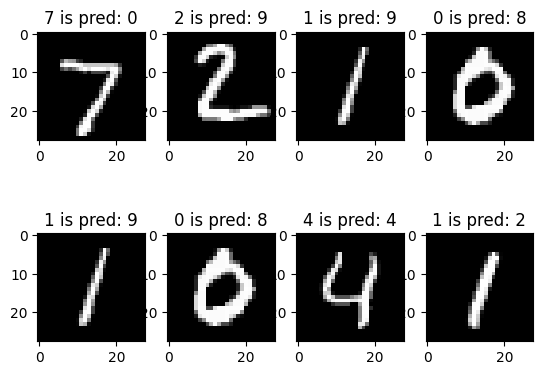

In [ ]:
for i in range(2):
  for j in range(4):
    plt.subplot(2,4,4 * i + j + 1)
    plt.imshow(x_test[2 * i + j].reshape(28, 28), cmap=plt.get_cmap("gray"))
    plt.title(f'{y_test[2 * i + j]} is pred: {predictions[0][2][2 * i + j]}')
plt.show()

In [ ]:
test_score = list()
for i in range(len(solvers)):
  temp_score = list()
  for j in range(len(activations)):
    test_evaluate =  models[i][j].evaluate(x_test, y_test, batch_size= 32)
    temp_score.append(test_evaluate)
  test_score.append(temp_score)

313/313 [==============================] - 0s 2ms/step - loss: 2.3592 - accuracy: 0.0709


In [ ]:
# import module
from tabulate import tabulate
# assign data
mydata = [
    ["SGD",test_score[0][0][1],test_score[0][1][1],test_score[0][2][1],test_score[0][3][1]],
    ["RMSprop",test_score[1][0][1],test_score[1][1][1],test_score[1][2][1],test_score[1][3][1]],
    ["Adam",test_score[2][0][1],test_score[2][1][1],test_score[2][2][1],test_score[2][3][1]],
    ["AdamW",test_score[3][0][1],test_score[3][1][1],test_score[3][2][1],test_score[3][3][1]],
    ["Adadelta",test_score[4][0][1],test_score[4][1][1],test_score[4][2][1],test_score[4][3][1]],
    ["Adagrad",test_score[5][0][1],test_score[5][1][1],test_score[5][2][1],test_score[5][3][1]],
    ["Adamax",test_score[6][0][1],test_score[6][1][1],test_score[6][2][1],test_score[6][3][1]],
    ["Adafactor",test_score[7][0][1],test_score[7][1][1],test_score[7][2][1],test_score[7][3][1]],
    ["Nadam",test_score[8][0][1],test_score[8][1][1],test_score[8][2][1],test_score[8][3][1]],
    ["Ftrl",test_score[9][0][1],test_score[9][1][1],test_score[9][2][1],test_score[9][3][1]]
    ]

# create header

head = ["Solver \ Activation", 'relu', 'selu', 'elu', 'tanh']
# display table
print("Test Score")
print(tabulate(mydata, headers=head, tablefmt="grid"))

Test Score
+-----------------------+--------+--------+--------+--------+
| Solver \ Activation   |   relu |   selu |    elu |   tanh |
+=======================+========+========+========+========+
| SGD                   | 0.1095 | 0.0811 | 0.1175 | 0.1174 |
+-----------------------+--------+--------+--------+--------+
| RMSprop               | 0.1076 | 0.0761 | 0.1042 | 0.0837 |
+-----------------------+--------+--------+--------+--------+
| Adam                  | 0.0998 | 0.1061 | 0.0977 | 0.1067 |
+-----------------------+--------+--------+--------+--------+
| AdamW                 | 0.1254 | 0.0904 | 0.0685 | 0.0734 |
+-----------------------+--------+--------+--------+--------+
| Adadelta              | 0.0848 | 0.0899 | 0.059  | 0.1071 |
+-----------------------+--------+--------+--------+--------+
| Adagrad               | 0.1115 | 0.1461 | 0.1134 | 0.0978 |
+-----------------------+--------+--------+--------+--------+
| Adamax                | 0.1478 | 0.0849 | 0.1303 | 0.0573

In [ ]:
train_score = list()
for i in range(len(solvers)):
  temp_score = list()
  for j in range(len(activations)):
    train_evaluate =  models[i][j].evaluate(x_train, y_train, batch_size= 32)
    temp_score.append(train_evaluate)
  train_score.append(temp_score)

1875/1875 [==============================] - 3s 2ms/step - loss: 2.3606 - accuracy: 0.0707


In [ ]:
# import module
from tabulate import tabulate
# assign data
mydata = [
    ["SGD",train_score[0][0][0],train_score[0][1][0],train_score[0][2][0],train_score[0][3][0]],
    ["RMSprop",train_score[1][0][0],train_score[1][1][0],train_score[1][2][0],train_score[1][3][0]],
    ["Adam",train_score[2][0][0],train_score[2][1][0],train_score[2][2][0],train_score[2][3][0]],
    ["AdamW",train_score[3][0][0],train_score[3][1][0],train_score[3][2][0],train_score[3][3][0]],
    ["Adadelta",train_score[4][0][0],train_score[4][1][0],train_score[4][2][0],train_score[4][3][0]],
    ["Adagrad",train_score[5][0][0],train_score[5][1][0],train_score[5][2][0],train_score[5][3][0]],
    ["Adamax",train_score[6][0][0],train_score[6][1][0],train_score[6][2][0],train_score[6][3][0]],
    ["Adafactor",train_score[7][0][0],train_score[7][1][0],train_score[7][2][0],train_score[7][3][0]],
    ["Nadam",train_score[8][0][0],train_score[8][1][0],train_score[8][2][0],train_score[8][3][0]],
    ["Ftrl",train_score[9][0][0],train_score[9][1][0],train_score[9][2][0],train_score[9][3][0]]
    ]

# create header

head = ["Solver \ Activation", 'relu', 'selu', 'elu', 'tanh']
# display table
print("Train Score")
print(tabulate(mydata, headers=head, tablefmt="grid"))

Train Score
+-----------------------+---------+---------+---------+---------+
| Solver \ Activation   |    relu |    selu |     elu |    tanh |
+=======================+=========+=========+=========+=========+
| SGD                   | 2.34489 | 2.55971 | 2.43245 | 2.38704 |
+-----------------------+---------+---------+---------+---------+
| RMSprop               | 2.3389  | 2.59082 | 2.35496 | 2.42806 |
+-----------------------+---------+---------+---------+---------+
| Adam                  | 2.42037 | 2.73798 | 2.41174 | 2.37456 |
+-----------------------+---------+---------+---------+---------+
| AdamW                 | 2.29154 | 2.68317 | 2.45257 | 2.44751 |
+-----------------------+---------+---------+---------+---------+
| Adadelta              | 2.33105 | 2.71764 | 2.46198 | 2.42594 |
+-----------------------+---------+---------+---------+---------+
| Adagrad               | 2.29855 | 2.43185 | 2.5571  | 2.45435 |
+-----------------------+---------+---------+---------+---------

In [ ]:
histories[0][0].history.keys()

dict_keys(['loss', 'accuracy'])

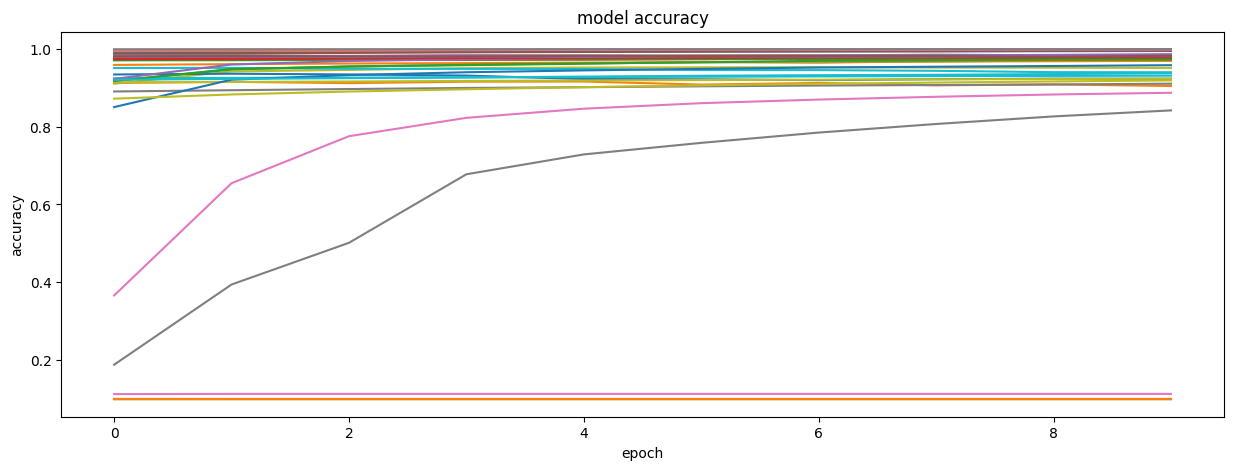

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(15,5))
colors = [['blue', 'orange', 'green', 'red', 'purple'],['brown', 'pink', 'gray', 'olive', 'cyan']]
for i in range(len(solvers)):
  for j in range(len(activations)):
    axes.plot(histories[i][j].history['accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
# axes.legend(['train'], loc='upper left')
plt.show()

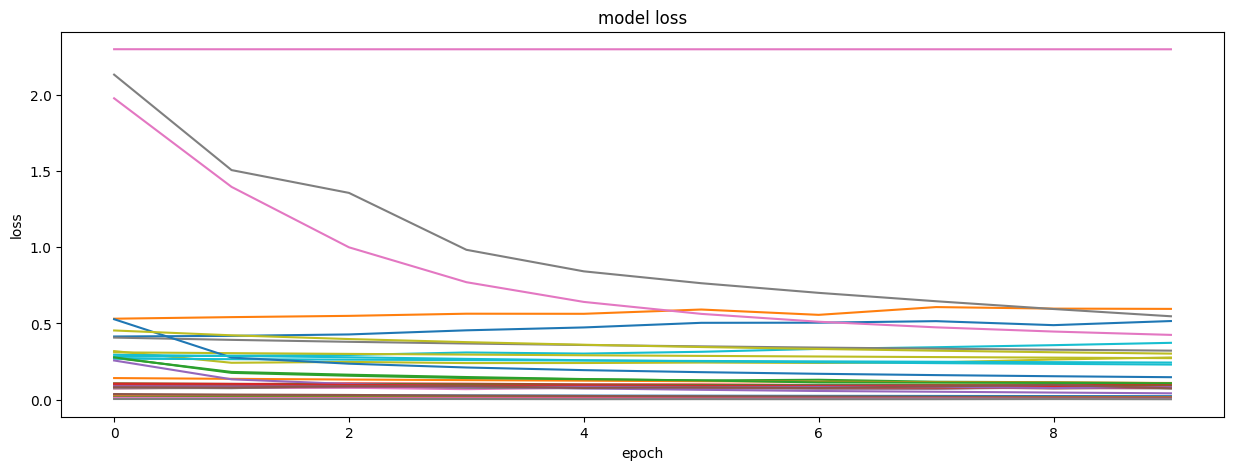

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(15,5))
colors = [['blue', 'orange', 'green', 'red', 'purple'],['brown', 'pink', 'gray', 'olive', 'cyan']]
for i in range(len(solvers)):
  for j in range(len(activations)):
    axes.plot(histories[i][j].history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
# axes.legend(['train'], loc='upper left')
plt.show()

In [ ]:
target_layer = 0 #0 is input, 1 is 1st hidden etc

In [ ]:
print(len(models[0][0].layers[target_layer].get_weights()[1])) #bias

50


In [ ]:
print(len(models[0][0].layers[target_layer].get_weights()[0])) #Weights

784


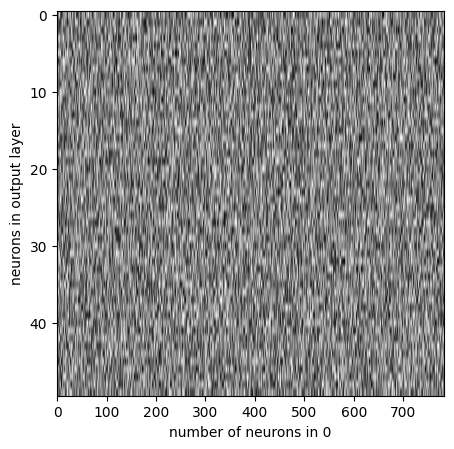

In [ ]:

fig, axes = plt.subplots(1, 1, figsize=(5,5))
axes.imshow(np.transpose(models[0][0].layers[target_layer].get_weights()[0]), cmap=plt.get_cmap("gray"), aspect="auto")
axes.set_xlabel(f"number of neurons in {target_layer}")
axes.set_ylabel("neurons in output layer")
plt.show()